## Imports

In [433]:
import numpy as np
from matplotlib import pyplot as plt

# Constants

In [434]:
DIM = 2
DATASIZE = 20

## Perceptron Learning Algorithm (PLA)

In [435]:
class PLA:
    def __init__(self, max_iterations=1000):
        self.max_iterations = max_iterations
        self.weights = None

    def fit(self, X, y):
        X_aug = np.hstack([X, np.ones((X.shape[0], 1))])
        self.weights = np.zeros(X_aug.shape[1])

        for i in range(self.max_iterations):
            errors = 0
            for idx, x_i in enumerate(X_aug):
                if y[idx] * np.dot(x_i, self.weights) <= 0:
                    self.weights += y[idx] * x_i
                    errors += 1
            if errors == 0:
                print("Converged after {} iterations".format(i + 1))
                break
        else:
            print('Not converged within the maximum iterations')

    def predict(self, X):
        X_aug = np.hstack([X, np.ones((X.shape[0], 1))])
        return np.sign(np.dot(X_aug, self.weights))

## Random Linear Boundary and Data

In [436]:
target_w = np.random.rand(DIM) * 2 - 1
target_b = np.random.rand() * 2 - 1

In [437]:
x_line = np.linspace(-1, 1, 100)
if DIM == 2:
    y_line = -(target_w[0] * x_line + target_b) / target_w[1]

In [439]:
X_data = np.random.rand(DATASIZE, DIM) * 2 - 1

labels = np.sign(X_data @ target_w + target_b)

# PLA on the Data

In [440]:
pla = PLA(max_iterations=1000)

pla.fit(X_data, labels)

Converged after 2 iterations


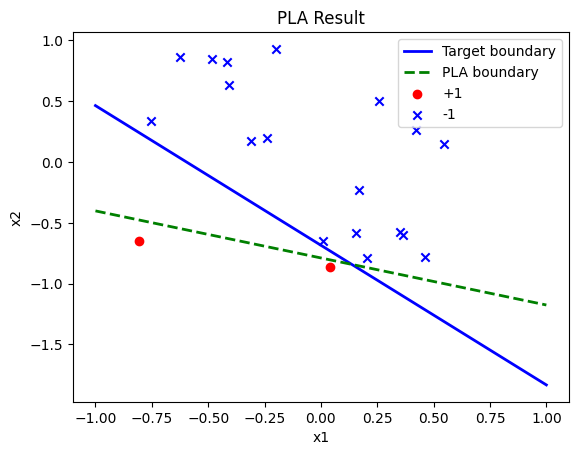

In [441]:
if DIM == 2:
    plt.plot(x_line, y_line, 'b-', linewidth=2, label='Target boundary')
    
    pla_w = pla.weights
    y_pla = -(pla_w[0] * x_line + pla_w[2]) / pla_w[1]
    plt.plot(x_line, y_pla, 'g--', linewidth=2, label='PLA boundary')
    
    plt.scatter(X_data[labels == 1, 0], X_data[labels == 1, 1], c='red', marker='o', label='+1')
    plt.scatter(X_data[labels == -1, 0], X_data[labels == -1, 1], c='blue', marker='x', label='-1')
    
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('PLA Result')
    plt.legend()
    plt.show()